<a href="https://colab.research.google.com/github/ashley-manzo/COSC-5360-AI-Projects/blob/main/AshleyManzoMidterm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data Loaded Successfully
Dataset shape: (114000, 21)


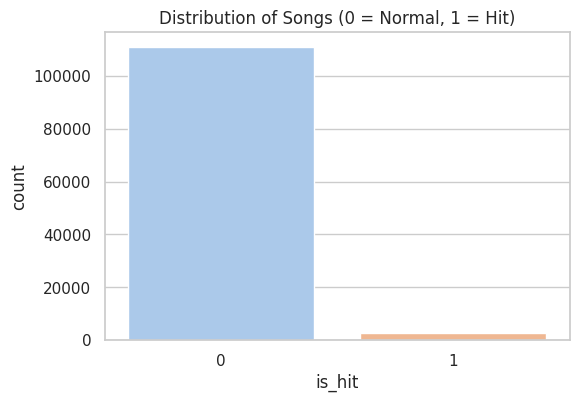

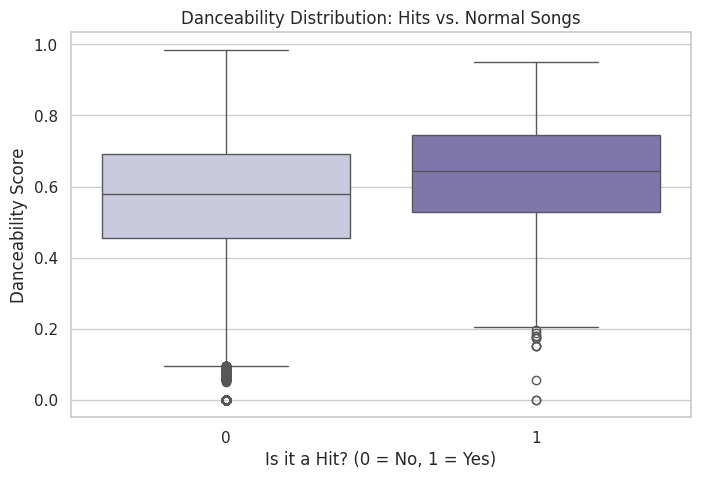

Starting Grid Search for Model Optimization...
Best Parameters Found: {'max_depth': 20, 'n_estimators': 50}
Optimized Validation Accuracy:  98.53%


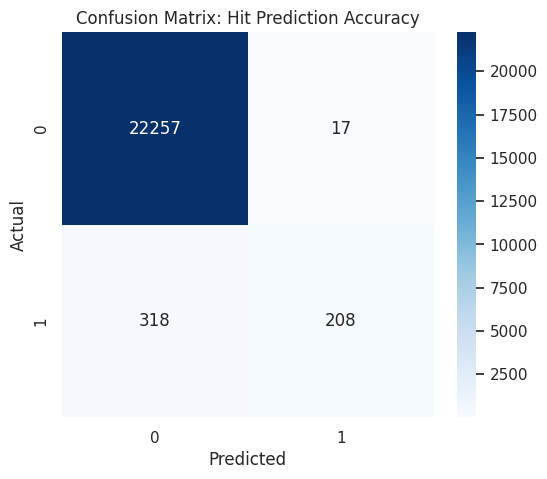

In [3]:
from re import X
# Midterm Project
# Ashley Manzo
# What Makes A Song A Radio Hit?

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Load data from Spotify
df = pd.read_csv('dataset.csv')

# cout >> "Data Loaded Successfully";
print('Data Loaded Successfully')
print('Dataset shape:', df.shape)

# Remove/drop rows with no/missing values
df = df.dropna()

# Hit song = 75 or higher (1), Normal = 74 and below (0)
df['is_hit'] = (df['popularity'] >= 75).astype(int)

sns.set(style='whitegrid')

plt.figure(figsize = (6, 4))
sns.countplot(data = df, x = 'is_hit', hue = 'is_hit', legend = False, palette = 'pastel')
plt.title('Distribution of Songs (0 = Normal, 1 = Hit)')
plt.show()

# Danceability
plt.figure(figsize = (8, 5))
sns.boxplot(data = df, x = 'is_hit', y = 'danceability', hue = 'is_hit', legend = False, palette = 'Purples')
plt.title('Danceability Distribution: Hits vs. Normal Songs')
plt.xlabel('Is it a Hit? (0 = No, 1 = Yes)')
plt.ylabel('Danceability Score')
plt.show()

features = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

X = df[features]
y  = df['is_hit']

# 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

rf_model = RandomForestClassifier (random_state = 42)

# cout >> "Starting Grid Search...";
print('Starting Grid Search for Model Optimization...')
param_grid = {
  'n_estimators': [50, 100],
  'max_depth': [10, 20]
}
grid_search = GridSearchCV(estimator = rf_model, param_grid = param_grid, cv = 3, n_jobs = -1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(f'Best Parameters Found: {grid_search.best_params_}')

predictions = best_model.predict(X_test)
acc = accuracy_score(y_test, predictions)
print(f'Optimized Validation Accuracy: {acc * 100: .2f}%')

cm = confusion_matrix(y_test, predictions)
plt.figure(figsize = (6, 5))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues')
plt.title('Confusion Matrix: Hit Prediction Accuracy')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()